# **Data Preprocessing**

In [2]:
# Cargar datos de excel
import pandas as pd
import numpy as np
from pathlib import Path
data_22june2020_1 = pd.read_excel('SWaT.A7_June 2020/22June2020 (1).xlsx')
data_22june2020_2 = pd.read_excel('SWaT.A7_June 2020/22June2020 (2).xlsx')
data_29june2020_1 = pd.read_excel('SWaT.A7_June 2020/29June2020 (1).xlsx')
data_29june2020_2 = pd.read_excel('SWaT.A7_June 2020/29June2020 (2).xlsx')

# ----------------------------
# 1. Cargar archivos originales
# ----------------------------
files = {
    "22June2020_1": data_22june2020_1.copy(),
    "22June2020_2": data_22june2020_2.copy(),
    "29June2020_1": data_29june2020_1.copy(),
    "29June2020_2": data_29june2020_2.copy(),
}

# ----------------------------
# 2. Hallar columnas comunes
# ----------------------------
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
print(f"Número de columnas comunes: {len(common_cols)}")

# Verificar cuáles quedaron fuera:
for name, df in files.items():
    extra = sorted(set(df.columns) - set(common_cols))
    if extra:
        print(f"{name} tiene columnas no comunes: {extra}")

# ----------------------------
# 3. Mantener solo columnas comunes y mismo orden
# ----------------------------
files = {name: df[common_cols].copy() for name, df in files.items()}

# ----------------------------
# 4. Función de limpieza básica
# ----------------------------
def clean_swat_df(df):
    df = df.copy()

    # Reemplazar valores inválidos
    df = df.replace("Bad Input", pd.NA)

    # ------------------------
    # Timestamp
    # ------------------------
    if "t_stamp" in df.columns:
        df["t_stamp"] = (
            df["t_stamp"]
            .astype(str)
            .str.replace("/yy ", "/2020 ", regex=False)
            .str.strip()
        )
        df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")

    # ------------------------
    # Variables continuas
    # ------------------------
    pv_cols = [c for c in df.columns if c.endswith(".Pv")]
    df[pv_cols] = df[pv_cols].apply(pd.to_numeric, errors="coerce")

    # ------------------------
    # Variables discretas
    # ------------------------
    status_cols = [c for c in df.columns if c.endswith(".Status")]
    state_cols = [c for c in df.columns if c.startswith("P") and c.endswith("_STATE")]

    df[status_cols + state_cols] = (
        df[status_cols + state_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype("Int64")  # entero con NaN permitido
    )

    return df

# ----------------------------
# 5. Aplicar limpieza
# ----------------------------
files_clean = {name: clean_swat_df(df) for name, df in files.items()}

# ----------------------------
# 6. Guardar
# ----------------------------
output_dir = Path("SWaT.A7_June2020_clean")
output_dir.mkdir(parents=True, exist_ok=True)

for name, df in files_clean.items():
    df.to_csv(output_dir / f"{name}.csv", index=False)

print("Archivos limpios guardados.")

Número de columnas comunes: 61
22June2020_1 tiene columnas no comunes: ['AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'DPSH301.Alarm', 'LS201.Alarm', 'LS202.Alarm', 'LS401.Alarm', 'LSH601.Alarm', 'LSH602.Alarm', 'LSH603.Alarm', 'LSL203.Alarm', 'LSL601.Alarm', 'LSL602.Alarm', 'LSL603.Alarm', 'LSLL203.Alarm', 'P207.Status', 'P208.Status', 'P603.Status', 'PSH301.Alarm', 'PSH501.Alarm', 'PSL501.Alarm']
22June2020_2 tiene columnas no comunes: ['AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'DPSH301.Alarm', 'LS201.Alarm', 'LS202.Alarm', 'LS401.Alarm', 'LSH601.Alarm', 'LSH602.Alarm', 'LSH603.Alarm', 'LSL203.Alarm', 'LSL601.Alarm', 'LSL602.Alarm', 'LSL603.Alarm', 'LSLL203.Alarm', 'P207.Status', 'P208.Status', 'P603.Status', 'PSH301.Alarm', 'PSH501.Alarm', 'PSL501.Alarm']
29June2020_1 tiene columnas no comunes: ['Unnamed: 100', 'Unnamed: 1000', 'Unnamed: 10000', 'Unnamed: 10001', 'Unnamed: 10002', 'Unnamed: 10003', 'Unnamed: 10004', 'Unnamed: 10005', 'Unnamed: 10006', 'Unnamed: 10007', 'Unnamed: 10008', 'Unna

## Identificar variables

In [3]:
# ============================
# Identificación automática de variables
# ============================

# Tomamos un dataframe de referencia, ya limpio y con columnas homologadas
sample_df = next(iter(files_clean.values()))

all_cols = sample_df.columns.tolist()

# Timestamp
timestamp_cols = [c for c in all_cols if c == "t_stamp"]

# Sensores continuos
pv_cols = [c for c in all_cols if c.endswith(".Pv")]

# Actuadores / estados discretos
status_cols = [c for c in all_cols if c.endswith(".Status")]
state_cols = [c for c in all_cols if c.startswith("P") and c.endswith("_STATE")]

# Otras columnas que no entraron en ninguna categoría
classified_cols = set(timestamp_cols + pv_cols + status_cols + state_cols)
other_cols = [c for c in all_cols if c not in classified_cols]

print("Resumen de variables detectadas")
print(f"Timestamp: {len(timestamp_cols)}")
print(f"Sensores continuos (.Pv): {len(pv_cols)}")
print(f"Actuadores discretos (.Status): {len(status_cols)}")
print(f"Estados discretos (_STATE): {len(state_cols)}")
print(f"Otras columnas no clasificadas: {len(other_cols)}")

if timestamp_cols:
    print("\nTimestamp:")
    print(timestamp_cols)

if other_cols:
    print("\nColumnas no clasificadas:")
    print(other_cols)

Resumen de variables detectadas
Timestamp: 1
Sensores continuos (.Pv): 25
Actuadores discretos (.Status): 29
Estados discretos (_STATE): 6
Otras columnas no clasificadas: 0

Timestamp:
['t_stamp']


In [4]:
print("\n--- Sensores continuos (.Pv) ---")
print(pv_cols)

print("\n--- Actuadores discretos (.Status) ---")
print(status_cols)

print("\n--- Estados discretos (_STATE) ---")
print(state_cols)


--- Sensores continuos (.Pv) ---
['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']

--- Actuadores discretos (.Status) ---
['MV101.Status', 'MV201.Status', 'MV301.Status', 'MV302.Status', 'MV303.Status', 'MV304.Status', 'MV501.Status', 'MV502.Status', 'MV503.Status', 'MV504.Status', 'P101.Status', 'P102.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'P301.Status', 'P302.Status', 'P401.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P501.Status', 'P502.Status', 'P601.Status', 'P602.Status', 'UV401.Status']

--- Estados discretos (_STATE) ---
['P1_STATE', 'P2_STATE', 'P3_STATE', 'P4_STATE', 'P5_STATE', 'P6_STATE']


In [7]:
# Features que sí entran al modelo
feature_cols = pv_cols + status_cols + state_cols

print(f"Total de features para el modelo: {len(feature_cols)}")
print(feature_cols[:10], "..." if len(feature_cols) > 10 else "")

Total de features para el modelo: 60
['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv'] ...


In [8]:
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print(f"Variables continuas a escalar: {len(continuous_cols)}")
print(f"Variables discretas sin escalar: {len(discrete_cols)}")

Variables continuas a escalar: 25
Variables discretas sin escalar: 35


## Perfilamiento

In [5]:
summary_rows = []

for name, df in files_clean.items():
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "cols": len(df.columns),
        "start_time": df["t_stamp"].min() if "t_stamp" in df.columns else None,
        "end_time": df["t_stamp"].max() if "t_stamp" in df.columns else None,
        "missing_total": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,rows,cols,start_time,end_time,missing_total
0,22June2020_1,14400,61,2020-06-22 10:00:00,2020-06-22 14:01:10.990,0
1,22June2020_2,3600,61,2020-06-22 09:00:00,2020-06-22 09:59:59.000,0
2,29June2020_1,7201,61,2020-06-29 10:00:00,2020-06-29 12:00:00.000,0
3,29June2020_2,7201,61,2020-06-29 13:30:00,2020-06-29 15:30:00.000,60


In [6]:
for name, df in files_clean.items():
    print(f"\n===== {name} =====")
    print("NaN en Pv:")
    print(df[pv_cols].isna().sum().sort_values(ascending=False).head(10))

    print("\nNaN en Status/STATE:")
    print(df[status_cols + state_cols].isna().sum().sort_values(ascending=False).head(10))


===== 22June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 22June2020_2 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 29June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
A

In [9]:
constant_cols = []
low_variation_cols = []

for col in feature_cols:
    nunique = sample_df[col].nunique(dropna=True)
    if nunique <= 1:
        constant_cols.append(col)
    elif nunique <= 2:
        low_variation_cols.append(col)

print("Columnas constantes:", constant_cols)
print("\nColumnas con muy baja variación:", low_variation_cols)

Columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'FIT504.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status', 'P4_STATE']

Columnas con muy baja variación: ['P101.Status', 'P201.Status', 'P203.Status', 'P205.Status', 'P301.Status', 'P401.Status', 'P501.Status', 'P601.Status', 'P602.Status', 'UV401.Status', 'P2_STATE', 'P6_STATE']


## Visualización de algunos sensores

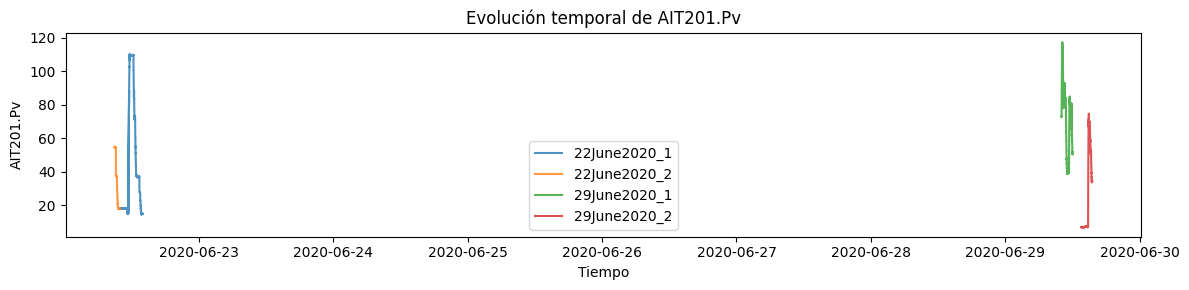

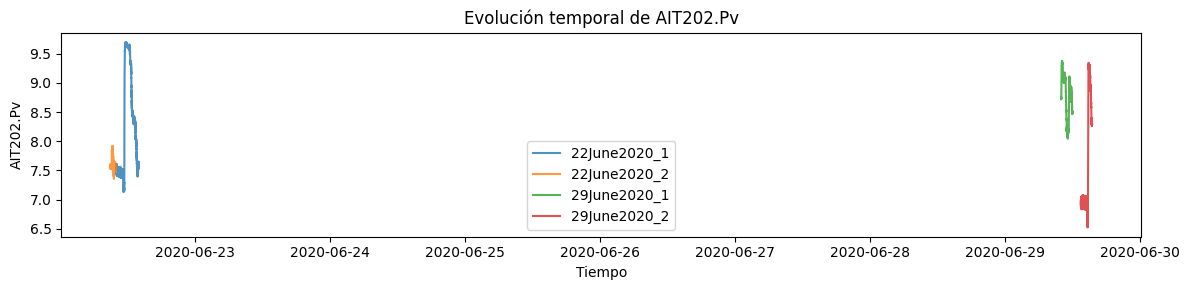

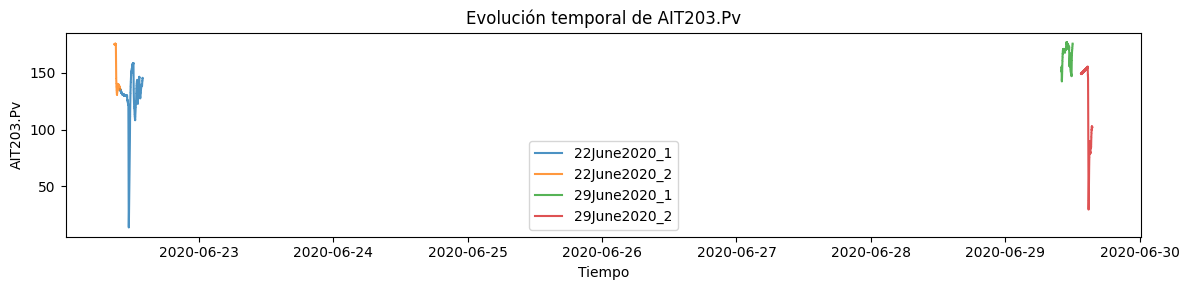

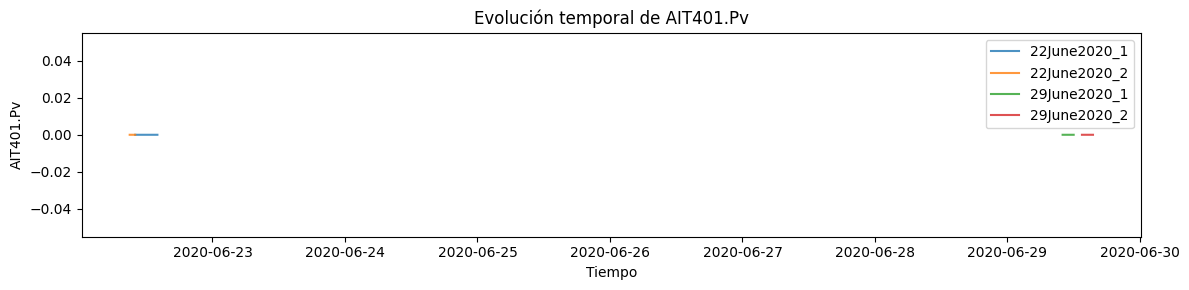

In [10]:
import matplotlib.pyplot as plt

example_pv = pv_cols[:4]  # puedes cambiar el número

for col in example_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files_clean.items():
        plt.plot(df["t_stamp"], df[col], label=name, alpha=0.8)
    plt.title(f"Evolución temporal de {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
for col in (status_cols + state_cols)[:6]:  # muestra algunas
    print(f"\n===== {col} =====")
    for name, df in files_clean.items():
        print(f"{name}:")
        print(df[col].value_counts(dropna=False).sort_index())


===== MV101.Status =====
22June2020_1:
MV101.Status
0       16
1    13582
2      802
Name: count, dtype: Int64
22June2020_2:
MV101.Status
1    3600
Name: count, dtype: Int64
29June2020_1:
MV101.Status
0      52
1    5829
2    1320
Name: count, dtype: Int64
29June2020_2:
MV101.Status
0         15
1       6714
2        471
<NA>       1
Name: count, dtype: Int64

===== MV201.Status =====
22June2020_1:
MV201.Status
0      63
1    8679
2    5658
Name: count, dtype: Int64
22June2020_2:
MV201.Status
0      16
1    2158
2    1426
Name: count, dtype: Int64
29June2020_1:
MV201.Status
0      28
1    1554
2    5619
Name: count, dtype: Int64
29June2020_2:
MV201.Status
0         24
1       4814
2       2362
<NA>       1
Name: count, dtype: Int64

===== MV301.Status =====
22June2020_1:
MV301.Status
0       43
1    14258
2       99
Name: count, dtype: Int64
22June2020_2:
MV301.Status
1    3600
Name: count, dtype: Int64
29June2020_1:
MV301.Status
1    7201
Name: count, dtype: Int64
29June2020_2:
MV301